# Comparative Analysis of FCN-ResNet50 and DeepLabV3+ for Semantic Segmentation on SENSATION and CamVid Datasets

## Abstract

This project presents a comparative study of two semantic segmentation architectures: FCN-ResNet50 and DeepLabV3+. The experiments are conducted on the SENSATION and CamVid datasets to evaluate segmentation performance in urban scene understanding. Both models are trained and evaluated using the same preprocessing pipeline, dataset split strategy, optimization settings, and evaluation metrics to ensure a fair comparison.

The evaluation includes Pixel Accuracy, Mean Intersection over Union, Dice Score, Precision, Recall, and Inference Time. Quantitative results are supported by qualitative visualizations of predicted segmentation masks and overlays. The study discusses the strengths, limitations, computational cost, and segmentation behavior of both architectures.

## Imports

In [1]:
from pathlib import Path
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Project directories
PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
REPORTS_DIR = PROJECT_ROOT / "reports"

for directory in [OUTPUTS_DIR, CHECKPOINTS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Using device: {DEVICE}")

if DEVICE.type == "cpu":
    print("Warning: CUDA is not available. Full training may be slow on CPU.")

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Using device: cuda


## Dataset Configuration

The initial experiments are conducted on the CamVid dataset because it is smaller than SENSATION and suitable for validating the complete experimental pipeline. CamVid consists of urban driving scenes with pixel-level semantic annotations. The dataset is already divided into training, validation, and test subsets.

The mask files are stored as class-index PNG images, where each pixel value corresponds to a semantic class. The `Unlabelled` class is treated as an ignored class during loss calculation and metric computation because it does not represent a meaningful semantic category.

In [6]:
# Dataset 1: CamVid
# Active datasets for the current experiment
ACTIVE_DATASETS = ["camvid"]

# CamVid dataset paths
CAMVID_ROOT = DATA_DIR / "camvid"

CAMVID_IMAGE_DIRS = {
    "train": CAMVID_ROOT / "images" / "train",
    "val": CAMVID_ROOT / "images" / "val",
    "test": CAMVID_ROOT / "images" / "test",
}

CAMVID_MASK_DIRS = {
    "train": CAMVID_ROOT / "masks" / "train",
    "val": CAMVID_ROOT / "masks" / "val",
    "test": CAMVID_ROOT / "masks" / "test",
}

# Standard CamVid 12-class setup used by many semantic segmentation implementations.
# The final class, Unlabelled, is treated as ignore/void.
CAMVID_CLASSES = {
    0: "Sky",
    1: "Building",
    2: "Pole",
    3: "Road",
    4: "Pavement",
    5: "Tree",
    6: "SignSymbol",
    7: "Fence",
    8: "Car",
    9: "Pedestrian",
    10: "Bicyclist",
    11: "Unlabelled",
}

CAMVID_NUM_CLASSES = len(CAMVID_CLASSES)
CAMVID_IGNORE_INDEX = 11

# Training configuration for the small CamVid experiment
IMAGE_SIZE = 256
BATCH_SIZE = 4
NUM_WORKERS = 0

print(f"CamVid classes: {CAMVID_NUM_CLASSES}")
print(f"Ignored class index: {CAMVID_IGNORE_INDEX} ({CAMVID_CLASSES[CAMVID_IGNORE_INDEX]})")

# Dataset 2: SENSATION
SENSATION_ROOT = DATA_DIR / "sensation"

SENSATION_IMAGE_DIRS = {
    "train": SENSATION_ROOT / "images" / "train",
    "val": SENSATION_ROOT / "images" / "val",
    "test": SENSATION_ROOT / "images" / "test",
}

SENSATION_MASK_DIRS = {
    "train": SENSATION_ROOT / "masks" / "train",
    "val": SENSATION_ROOT / "masks" / "val",
    "test": SENSATION_ROOT / "masks" / "test",
}

# Placeholder class mapping based on the project specification.
# Verify these labels against the official SENSATION annotation documentation
# before final training and reporting.
SENSATION_CLASSES = {
    0: "background",
    1: "road",
    2: "sidewalk",
    3: "crosswalk",
    4: "bikelane",
    5: "person",
    6: "car",
    7: "bicycle",
    8: "traffic sign",
    9: "traffic light",
    10: "obstacle",
    11: "stairs",
}

SENSATION_NUM_CLASSES = len(SENSATION_CLASSES)

# Set this to an integer if the SENSATION dataset has a void/unlabelled class.
# Keep as None if all classes should be used for loss and metrics.
SENSATION_IGNORE_INDEX = None

print("SENSATION dataset is configured but not active yet.")
print(f"SENSATION expected classes: {SENSATION_NUM_CLASSES}")

CamVid classes: 12
Ignored class index: 11 (Unlabelled)
SENSATION dataset is configured but not active yet.
SENSATION expected classes: 12


In [7]:
def verify_segmentation_structure(
    image_dirs: dict[str, Path],
    mask_dirs: dict[str, Path],
    dataset_name: str,
) -> pd.DataFrame:
    rows = []

    for split in ["train", "val", "test"]:
        image_dir = image_dirs[split]
        mask_dir = mask_dirs[split]

        if not image_dir.exists() or not mask_dir.exists():
            rows.append({
                "dataset": dataset_name,
                "split": split,
                "images": 0,
                "masks": 0,
                "matched_pairs": 0,
                "missing_masks": "folder missing",
                "missing_images": "folder missing",
            })
            continue

        image_files = sorted(image_dir.glob("*.png"))
        mask_files = sorted(mask_dir.glob("*.png"))

        image_names = {p.name for p in image_files}
        mask_names = {p.name for p in mask_files}

        missing_masks = sorted(image_names - mask_names)
        missing_images = sorted(mask_names - image_names)

        rows.append({
            "dataset": dataset_name,
            "split": split,
            "images": len(image_files),
            "masks": len(mask_files),
            "matched_pairs": len(image_names & mask_names),
            "missing_masks": len(missing_masks),
            "missing_images": len(missing_images),
        })

    return pd.DataFrame(rows)


def inspect_dataset_mask_values(
    mask_dirs: dict[str, Path],
    dataset_name: str,
) -> list[int] | None:
    existing_mask_files = []

    for split in ["train", "val", "test"]:
        mask_dir = mask_dirs[split]

        if mask_dir.exists():
            existing_mask_files.extend(sorted(mask_dir.glob("*.png")))

    if not existing_mask_files:
        print(f"{dataset_name}: no mask files found yet.")
        return None

    values = set()

    for mask_path in existing_mask_files:
        mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

        if mask is None:
            raise ValueError(f"Could not read mask: {mask_path}")

        if mask.ndim == 3:
            print(
                f"{dataset_name}: RGB/color mask detected at {mask_path.name}. "
                "A color-to-class mapping will be required."
            )
            return None

        values.update(np.unique(mask).astype(int).tolist())

    return sorted(values)

In [ ]:
# Verify CamVid
camvid_summary = verify_segmentation_structure(
    CAMVID_IMAGE_DIRS,
    CAMVID_MASK_DIRS,
    dataset_name="CamVid",
)

display(camvid_summary)

camvid_mask_values = inspect_dataset_mask_values(
    CAMVID_MASK_DIRS,
    dataset_name="CamVid",
)

print("CamVid mask values:", camvid_mask_values)

# Verify SENSATION
sensation_summary = verify_segmentation_structure(
    SENSATION_IMAGE_DIRS,
    SENSATION_MASK_DIRS,
    dataset_name="SENSATION",
)

display(sensation_summary)

sensation_mask_values = inspect_dataset_mask_values(
    SENSATION_MASK_DIRS,
    dataset_name="SENSATION",
)

print("SENSATION mask values:", sensation_mask_values)

,dataset,split,images,masks,matched_pairs,missing_masks,missing_images
0,CamVid,train,367,367,367,0,0
1,CamVid,val,101,101,101,0,0
2,CamVid,test,233,233,233,0,0


CamVid mask values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


,dataset,split,images,masks,matched_pairs,missing_masks,missing_images
0,SENSATION,train,0,0,0,folder missing,folder missing
1,SENSATION,val,0,0,0,folder missing,folder missing
2,SENSATION,test,0,0,0,folder missing,folder missing


SENSATION: no mask files found yet.
SENSATION mask values: None


## Visual Verification of Image-Mask Alignment

Before model training, image-mask alignment is verified visually. This step is essential because semantic segmentation uses pixel-level supervision. If an image is paired with the wrong mask, or if the mask is spatially misaligned, the training process becomes invalid.

A sample CamVid image is displayed together with its raw class-index mask, a colorized semantic mask, and an overlay visualization.

In [13]:
DATASET_CONFIGS = {
    "camvid": {
        "name": "CamVid",
        "image_dirs": CAMVID_IMAGE_DIRS,
        "mask_dirs": CAMVID_MASK_DIRS,
        "classes": CAMVID_CLASSES,
        "num_classes": CAMVID_NUM_CLASSES,
        "ignore_index": CAMVID_IGNORE_INDEX,
        "palette": {
            0: (128, 128, 128),   # Sky
            1: (128, 0, 0),       # Building
            2: (192, 192, 128),   # Pole
            3: (128, 64, 128),    # Road
            4: (60, 40, 222),     # Pavement
            5: (128, 128, 0),     # Tree
            6: (192, 128, 128),   # SignSymbol
            7: (64, 64, 128),     # Fence
            8: (64, 0, 128),      # Car
            9: (64, 64, 0),       # Pedestrian
            10: (0, 128, 192),    # Bicyclist
            11: (0, 0, 0),        # Unlabelled
        },
    },
    "sensation": {
        "name": "SENSATION",
        "image_dirs": SENSATION_IMAGE_DIRS,
        "mask_dirs": SENSATION_MASK_DIRS,
        "classes": SENSATION_CLASSES,
        "num_classes": SENSATION_NUM_CLASSES,
        "ignore_index": SENSATION_IGNORE_INDEX,
        "palette": {
            0: (0, 0, 0),         # background
            1: (128, 64, 128),    # road
            2: (244, 35, 232),    # sidewalk
            3: (250, 170, 160),   # crosswalk
            4: (230, 150, 140),   # bikelane
            5: (220, 20, 60),     # person
            6: (0, 0, 142),       # car
            7: (119, 11, 32),     # bicycle
            8: (220, 220, 0),     # traffic sign
            9: (250, 170, 30),    # traffic light
            10: (102, 102, 156),  # obstacle
            11: (70, 70, 70),     # stairs
        },
    },
}

In [14]:
def load_image_rgb(image_path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def load_mask_index(mask_path: Path) -> np.ndarray:
    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")

    if mask.ndim == 3:
        raise ValueError(
            f"Expected class-index mask, but found RGB/color mask: {mask_path}. "
            "A color-to-class conversion mapping is required before training."
        )

    return mask.astype(np.int64)


def colorize_mask(
    mask: np.ndarray,
    palette: dict[int, tuple[int, int, int]],
) -> np.ndarray:
    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)

    for class_id, color in palette.items():
        color_mask[mask == class_id] = color

    return color_mask


def overlay_mask_on_image(
    image: np.ndarray,
    color_mask: np.ndarray,
    alpha: float = 0.45,
) -> np.ndarray:
    return cv2.addWeighted(
        image.astype(np.uint8),
        1 - alpha,
        color_mask.astype(np.uint8),
        alpha,
        0,
    )

In [15]:
def visualize_dataset_sample(
    dataset_key: str,
    split: str = "train",
    sample_index: int = 0,
) -> None:
    config = DATASET_CONFIGS[dataset_key]

    image_dir = config["image_dirs"][split]
    mask_dir = config["mask_dirs"][split]
    palette = config["palette"]

    if not image_dir.exists() or not mask_dir.exists():
        print(f"{config['name']} {split}: image or mask folder does not exist yet.")
        return

    image_paths = sorted(image_dir.glob("*.png"))

    if not image_paths:
        print(f"{config['name']} {split}: no PNG images found.")
        return

    if sample_index >= len(image_paths):
        raise IndexError(
            f"sample_index={sample_index} is out of range for "
            f"{config['name']} {split}, which has {len(image_paths)} images."
        )

    image_path = image_paths[sample_index]
    mask_path = mask_dir / image_path.name

    if not mask_path.exists():
        raise FileNotFoundError(f"Missing mask for image: {image_path.name}")

    image = load_image_rgb(image_path)
    mask = load_mask_index(mask_path)

    if image.shape[:2] != mask.shape[:2]:
        raise ValueError(
            f"Image and mask dimensions do not match for {image_path.name}: "
            f"image={image.shape[:2]}, mask={mask.shape[:2]}"
        )

    color_mask = colorize_mask(mask, palette)
    overlay = overlay_mask_on_image(image, color_mask)

    print(f"Dataset: {config['name']}")
    print(f"Split: {split}")
    print(f"Sample: {image_path.name}")
    print(f"Image shape: {image.shape}")
    print(f"Mask shape: {mask.shape}")
    print(f"Mask values: {sorted(np.unique(mask).tolist())}")

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(image)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="tab20")
    axes[1].set_title("Raw Class-Index Mask")
    axes[1].axis("off")

    axes[2].imshow(color_mask)
    axes[2].set_title("Colorized Mask")
    axes[2].axis("off")

    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

Dataset: CamVid
Split: train
Sample: 0001TP_006690.png
Image shape: (360, 480, 3)
Mask shape: (360, 480)
Mask values: [0, 1, 2, 3, 4, 5, 6, 8, 9, 11]


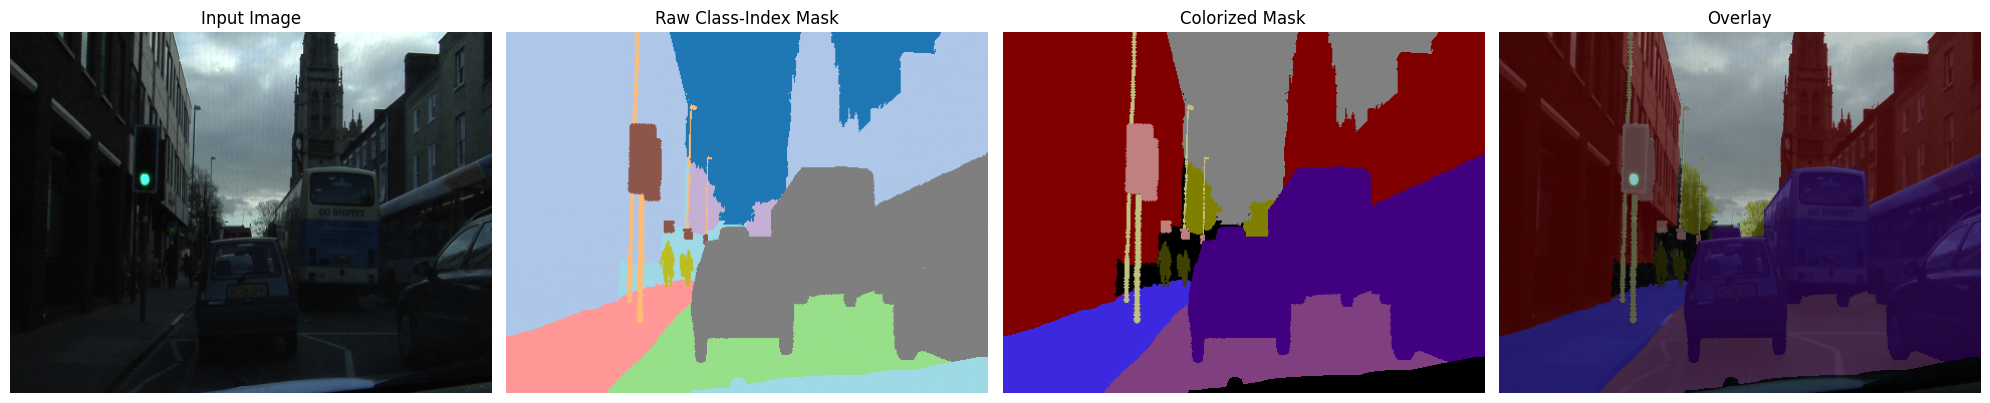

In [16]:
visualize_dataset_sample("camvid", split="train", sample_index=0)

In [17]:
visualize_dataset_sample("sensation", split="train", sample_index=0)

SENSATION train: image or mask folder does not exist yet.


## PyTorch Dataset and DataLoader

A custom PyTorch `Dataset` is used to load semantic segmentation image-mask pairs. Each image is resized, normalized, and converted into a tensor. Each mask is resized using nearest-neighbor interpolation to preserve integer class labels.

The same dataset class is reused for CamVid and SENSATION to ensure that both datasets follow the same preprocessing logic. This supports a fair comparison between FCN-ResNet50 and DeepLabV3+.

In [19]:
class SegmentationDataset(Dataset):
    def __init__(
        self,
        image_dir: Path,
        mask_dir: Path,
        image_size: int,
        num_classes: int,
        ignore_index: int | None = None,
    ):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size = image_size
        self.num_classes = num_classes
        self.ignore_index = ignore_index

        self.image_paths = sorted(self.image_dir.glob("*.png"))

        if not self.image_paths:
            raise FileNotFoundError(f"No PNG images found in {self.image_dir}")

        self.samples = []

        for image_path in self.image_paths:
            mask_path = self.mask_dir / image_path.name

            if not mask_path.exists():
                raise FileNotFoundError(f"Missing mask for image: {image_path.name}")

            self.samples.append((image_path, mask_path))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        image_path, mask_path = self.samples[index]

        image = load_image_rgb(image_path)
        mask = load_mask_index(mask_path)

        if image.shape[:2] != mask.shape[:2]:
            raise ValueError(
                f"Image and mask dimensions do not match for {image_path.name}: "
                f"image={image.shape[:2]}, mask={mask.shape[:2]}"
            )

        image = cv2.resize(
            image,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR,
        )

        mask = cv2.resize(
            mask,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_NEAREST,
        )

        invalid_mask_values = set(np.unique(mask).astype(int).tolist()) - set(range(self.num_classes))

        if invalid_mask_values:
            raise ValueError(
                f"Invalid mask values in {mask_path.name}: {sorted(invalid_mask_values)}"
            )

        image = image.astype(np.float32) / 255.0

        # ImageNet normalization, appropriate for ResNet50 encoders pretrained on ImageNet.
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

        image = (image - mean) / std

        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask).long()

        return image_tensor, mask_tensor

In [20]:
def create_dataloaders(
    dataset_key: str,
    image_size: int = IMAGE_SIZE,
    batch_size: int = BATCH_SIZE,
    num_workers: int = NUM_WORKERS,
) -> dict[str, DataLoader]:
    config = DATASET_CONFIGS[dataset_key]

    dataloaders = {}

    for split in ["train", "val", "test"]:
        dataset = SegmentationDataset(
            image_dir=config["image_dirs"][split],
            mask_dir=config["mask_dirs"][split],
            image_size=image_size,
            num_classes=config["num_classes"],
            ignore_index=config["ignore_index"],
        )

        dataloaders[split] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(split == "train"),
            num_workers=num_workers,
            pin_memory=(DEVICE.type == "cuda"),
        )

        print(
            f"{config['name']} {split}: "
            f"{len(dataset)} samples, "
            f"{len(dataloaders[split])} batches"
        )

    return dataloaders

In [21]:
camvid_loaders = create_dataloaders("camvid")

CamVid train: 367 samples, 92 batches
CamVid val: 101 samples, 26 batches
CamVid test: 233 samples, 59 batches


In [22]:
images, masks = next(iter(camvid_loaders["train"]))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)
print("Mask min:", masks.min().item())
print("Mask max:", masks.max().item())

Image batch shape: torch.Size([4, 3, 256, 256])
Mask batch shape: torch.Size([4, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.int64
Mask min: 0
Mask max: 11


## Model Architectures

In [ ]:
# TODO: Define FCN-ResNet50 and DeepLabV3+ models for 12-class segmentation

## Training Setup

In [ ]:
# TODO: Set up loss function, optimizer, and training loop

## Training

In [ ]:
# TODO: Train the model

## Evaluation

In [ ]:
# TODO: Evaluate model on test set

## Visualization

In [ ]:
# TODO: Visualize predictions